#import packages







In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler #it normalize the features
from sklearn.model_selection import train_test_split
#modules for Deep Learning
from keras.models import Sequential #It is a class which helps to create linear stack of Neural Network Layres
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

#Loading Dataset

In [124]:
df = pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


#Preprocessing

In [125]:
df.shape

(20640, 10)

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


#We have to encoding the part "ocean_proximity"

In [127]:
df['ocean_proximity'].value_counts() #We have to convert this object to Numarical

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


#Let check NULL values

In [128]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


#in "total_bedrooms" the amount of missing value is 207 . Though this data is so large we can drop them.

In [129]:
df.dropna(inplace=True)#dropna helps to drop data which are NULL

In [130]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


#Encoding

In [131]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9034
INLAND,6496
NEAR OCEAN,2628
NEAR BAY,2270
ISLAND,5


In [132]:
df['ocean_proximity'] = df['ocean_proximity'].map({"<1H OCEAN":0,"INLAND":1,"NEAR OCEAN":2,"NEAR BAY":3,"ISLAND":4})

#Our output Column is "**median_house_value**"

In [133]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1


#Declearing our **Features and Output**

In [134]:
x = df.drop("median_house_value",axis=1) # input column/ features
y = df['median_house_value']# output column

#Convert to numpy Array

In [135]:
x = np.array(x)
y = np.array(y)

In [136]:
x

array([[-1.2223e+02,  3.7880e+01,  4.1000e+01, ...,  1.2600e+02,
         8.3252e+00,  3.0000e+00],
       [-1.2222e+02,  3.7860e+01,  2.1000e+01, ...,  1.1380e+03,
         8.3014e+00,  3.0000e+00],
       [-1.2224e+02,  3.7850e+01,  5.2000e+01, ...,  1.7700e+02,
         7.2574e+00,  3.0000e+00],
       ...,
       [-1.2122e+02,  3.9430e+01,  1.7000e+01, ...,  4.3300e+02,
         1.7000e+00,  1.0000e+00],
       [-1.2132e+02,  3.9430e+01,  1.8000e+01, ...,  3.4900e+02,
         1.8672e+00,  1.0000e+00],
       [-1.2124e+02,  3.9370e+01,  1.6000e+01, ...,  5.3000e+02,
         2.3886e+00,  1.0000e+00]])

#Train Test split

#80% data to x_train from input(x) and 80% data fron y_train fron output(y)

In [137]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size= 0.2,random_state=42)

In [138]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(16346, 9)
(4087, 9)
(16346,)
(4087,)


#Scaling (To ensure **equal importance**) -> MinMaxScaler() ranged the value between 0 & 1

In [139]:
min_max_scaler = MinMaxScaler()
x_train = min_max_scaler.fit_transform(x_train)
x_test = min_max_scaler.fit_transform(x_test)


In [140]:
x_train

array([[0.25809717, 0.50797024, 0.25490196, ..., 0.14635751, 0.28984428,
        0.        ],
       [0.47773279, 0.4357067 , 0.62745098, ..., 0.02844927, 0.20074206,
        0.25      ],
       [0.63663968, 0.16790648, 0.47058824, ..., 0.12465055, 0.21820389,
        0.25      ],
       ...,
       [0.60020243, 0.15621679, 0.80392157, ..., 0.05936524, 0.1792458 ,
        0.        ],
       [0.23380567, 0.53453773, 0.21568627, ..., 0.17365565, 0.33020234,
        0.75      ],
       [0.19433198, 0.55154091, 1.        , ..., 0.10623253, 0.23403125,
        0.75      ]])

#Model Training & Archticture

#Sequential is the simplest way to build a neural network where layers are arranged in order - the output of one layer becomes the input of the next.

In [141]:
model = Sequential([
    #input Layer
    #Hidden Layer 01
    #Hidden Layer 02
    #..............
    #..............
    #Hidden Layer n
    #Output Layer
])


In [142]:
x_train.shape

(16346, 9)

#Dense() helps to create **Layers** and we pass the numbers of Neurons inside it.
#We use here **RELU** as activation function Because is useful for Training Regration Model. But If it was a Classification problem we can try Sigmoid Function.

In [143]:
model = Sequential([
    #input Layer
    Dense(1000, input_shape=(x_train.shape[1],), activation='relu'),
    #Hidden Layer 01
    Dense(500, activation='relu'),
    #Hidden Layer 02
    Dense(250, activation='relu'),
    #..............
    #..............
    #Hidden Layer n
    #Output Layer
    Dense(1,activation='linear')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 1000)           │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │           251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 636,001 (2.43 MB)

 Trainable params: 636,001 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

#Let's Compile

#**optimizer =Root Mean Squre Propagation**

#**Loss Function =Mean Squre  Error**

#**y = Actual - predicted**

In [144]:
model.compile(optimizer='rmsprop',
              loss='mse',           # Used for training (optimization)
              metrics=['mae'])      # Used for monitoring (evaluation)
es = EarlyStopping(monitor='val_loss',mode='min',patience=50,restore_best_weights=True)

#Let's fit/ **RUN** the model

In [145]:
history = model.fit(x_train, y_train,
          validation_data=(x_test, y_test),
          callbacks=[es],
          epochs=10,
          batch_size=50,
          verbose=1)

Epoch 1/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 26535811072.0000 - mae: 125519.4609 - val_loss: 11617227776.0000 - val_mae: 86780.0859
Epoch 2/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 9665260544.0000 - mae: 78020.4844 - val_loss: 8205394432.0000 - val_mae: 74164.3359
Epoch 3/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 6479193600.0000 - mae: 61180.2539 - val_loss: 6070041600.0000 - val_mae: 56241.2461
Epoch 4/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 5810391552.0000 - mae: 56076.4102 - val_loss: 5839212032.0000 - val_mae: 54833.6953
Epoch 5/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5638217728.0000 - mae: 54991.5859 - val_loss: 5911512576.0000 - val_mae: 53785.2188
Epoch 6/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 5463821824.0000 - mae: 53837.0000 - val_loss: 5552797696.0000 - val_mae: 53514.6797
Epoch 7/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5304075264.0000 - mae: 52893.1836 - val_loss: 5935243264.0000 - va

#models results and metrics

In [146]:
y_pred = model.predict(x_test)

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [147]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error
)
y_pred = model.predict(x_test)

print("mean_absolute_error:", mean_absolute_error(y_test,y_pred))
print("mean_squared_error:", mean_squared_error(y_test,y_pred))
print("mean_squared_log_error:", mean_squared_log_error(y_test,y_pred))
print('Score :',r2_score(y_test,y_pred))

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
mean_absolute_error: 53514.67913285823
mean_squared_error: 5552797602.155007
mean_squared_log_error: 0.15683799605454377
Score : 0.5939506987856478


#let's **Plot**

In [148]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
epochs = range(1,len(training_loss)+1)

In [149]:
epochs

range(1, 11)

#Plot the training and validation loss

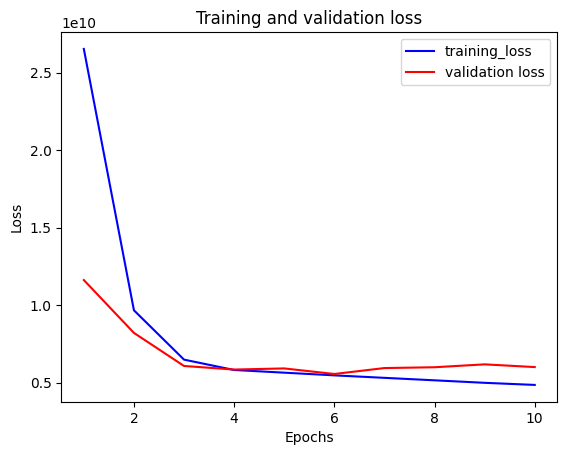

In [150]:
plt.plot(epochs, training_loss, 'b' ,label= "training_loss")
plt.plot(epochs, validation_loss, 'r' ,label= "validation loss")

plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
#Show the plot
plt.show()

#Testing by Features

In [151]:
# def pred(longitude ,	latitude ,	housing_median_age ,	total_rooms ,	total_bedrooms ,	population ,	households ,	median_income ,	median_house_value ,	ocean_proximity):
#   features = np.array([longitude ,	latitude ,	housing_median_age ,	total_rooms ,	total_bedrooms ,	population ,	households ,	median_income ,	median_house_value ,	ocean_proximity])
#   features_scaled = min_max_scaler.fit_transfrom([features])
#   result = model.predict(features_scaled).reshape(1,-1)
#   return result[0]

In [153]:
def predict_price(longitude,
                  latitude,
                  housing_median_age,
                  total_rooms,
                  total_bedrooms,
                  population,
                  households,
                  median_income,
                  ocean_proximity):
    """
    Predict house price based on input features
    """
    # Create feature array (excluding median_house_value - that's what we're predicting!)
    features = np.array([[longitude,
                          latitude,
                          housing_median_age,
                         total_rooms,
                          total_bedrooms,
                          population,
                         households,
                          median_income,
                          ocean_proximity]])

    # Scale features (use transform, not fit_transform!)
    features_scaled = scaler.transform(features)

    # Make prediction
    prediction = model.predict(features_scaled)

    return prediction[0][0]  # Return single value

In [159]:
import numpy as np

def predict_price(longitude, latitude, housing_median_age, total_rooms,
                  total_bedrooms, population, households, median_income,
                  ocean_proximity):
    """
    Predict house price with numeric ocean_proximity encoding
    """
    # Create feature array (with encoded ocean_proximity as number)
    features = np.array([[
        longitude,
        latitude,
        housing_median_age,
        total_rooms,
        total_bedrooms,
        population,
        households,
        median_income,
        ocean_proximity  # Already encoded as 3.00
    ]])

    # Scale features using the trained scaler
    features_scaled = min_max_scaler.transform(features)

    # Make prediction
    prediction = model.predict(features_scaled)

    return prediction[0][0]

# Test with your values
price = predict_price(
    longitude=-122.23,
    latitude=37.88,
    housing_median_age=41.00,
    total_rooms=880.00,
    total_bedrooms=880.00,
    population=322.00,
    households=126.00,
    median_income=8.3252,
    ocean_proximity=3.00
)

print(f"Predicted house price: ${price:,.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted house price: $458,966.97
